# 02 — Modelado Supervisado (Clasificación Multivariante)

En esta etapa aplicaremos algoritmos de Machine Learning para predecir si un estudiante será clasificado como `BAJA_RETENCION` o se mantendrá como `REGULAR`.

**Mejora Crítica:** Hemos incorporado variables categóricas (Sede, Carrera) junto con las numéricas, utilizando un `ColumnTransformer` para aplicar Escalado y OneHotEncoding.

In [1]:
%load_ext kedro.ipython

[05/15/26 15:23:23] INFO     Using                                                                  ]8;id=14681822;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py\__init__.py]8;;\:]8;id=14681823;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/framework/project/__init__.py#275\275]8;;\
                             '/Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/py                
                             thon3.12/site-packages/kedro/framework/project/rich_logging.yml' as                   
                             logging configuration.                                                                

                    INFO     Registered line magic '%reload_kedro'                                   ]8;id=14681830;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14681831;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#64\64]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=14681837;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14681838;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#66\66]8;;\

                    INFO     Resolved project path as:                                              ]8;id=14681844;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14681845;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#181\181]8;;\
                             /Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe.                             
                             To set a different path, run '%reload_kedro <project_root>'                           

[05/15/26 15:23:24] INFO     No typed parameter requirements found, returning original   ]8;id=14681852;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py\parameter_validator.py]8;;\:]8;id=14681853;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/validation/parameter_validator.py#108\108]8;;\
                             parameters                                                                            

                    INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=14681860;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro_telemetry/plugin.py\plugin.py]8;;\:]8;id=14681861;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro_telemetry/plugin.py#242\242]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Kedro project ev_parcial1_uribe                                        ]8;id=14681867;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14681868;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#147\147]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=14681874;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py\__init__.py]8;;\:]8;id=14681875;file:///Users/unk/Desktop/ev2-ciencia-datos/ev_parcial2ds_uribe/.venv/lib/python3.12/site-packages/kedro/ipython/__init__.py#148\148]8;;\
                             'pipelines'                                                                           

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid", context="notebook")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").is_file() and (PROJECT_ROOT.parent / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "03_primary" / "tabla_maestra.csv"


## 1. Carga, Filtrado y Particionamiento de Datos

In [3]:
df = pd.read_csv(DATA_PATH)

# Unificación de Clases (Data Starvation)
df['estado_matricula'] = df['estado_matricula'].replace(['CONGELADA', 'DESERTOR'], 'BAJA_RETENCION')

num_cols = ["total_ausencias", "promedio_notas", "semestre"]
cat_cols = ["carrera", "sede"]
target_col = "estado_matricula"

# Limpieza Estricta: Drop nulos para evitar errores en transformaciones
df_ml = df.dropna(subset=num_cols + cat_cols + [target_col]).copy()

X = df_ml[num_cols + cat_cols]
y = df_ml[target_col]

# Separación estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño de Entrenamiento: {X_train.shape}")
print(f"Tamaño de Prueba: {X_test.shape}")

Tamaño de Entrenamiento: (424, 5)
Tamaño de Prueba: (107, 5)


## 2. Construcción del Preprocesador (ColumnTransformer)
Aplicamos Normalización (`StandardScaler`) a las variables numéricas y codificación One-Hot (`OneHotEncoder`) a las variables nominales.

In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

## 3. Definición de Modelos a Evaluar

In [5]:
# Configurar los Pipelines Integrados
pipelines = {
    "Regresión Logística": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Support Vector Classifier": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', SVC(random_state=42))
    ]),
    "Random Forest (Balanced)": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
    ])
}

## 4. Entrenamiento y Evaluación

Entrenando Regresión Logística...

--- Reporte de Clasificación ---
                precision    recall  f1-score   support

BAJA_RETENCION       0.33      0.19      0.24        27
      EGRESADO       1.00      0.36      0.53        11
       REGULAR       0.69      0.88      0.78        69

      accuracy                           0.65       107
     macro avg       0.68      0.48      0.52       107
  weighted avg       0.63      0.65      0.62       107



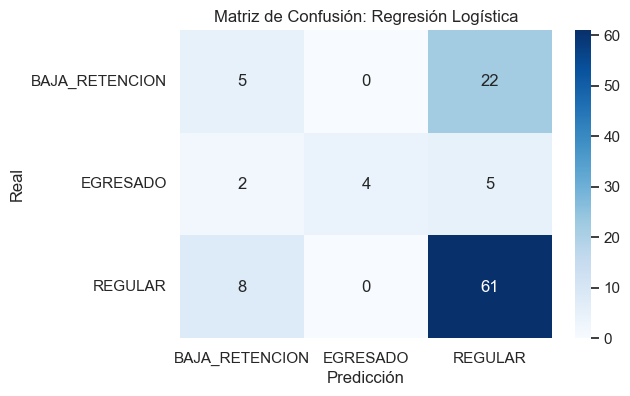

Entrenando Support Vector Classifier...

--- Reporte de Clasificación ---
                precision    recall  f1-score   support

BAJA_RETENCION       0.46      0.22      0.30        27
      EGRESADO       1.00      0.36      0.53        11
       REGULAR       0.69      0.90      0.78        69

      accuracy                           0.67       107
     macro avg       0.72      0.49      0.54       107
  weighted avg       0.66      0.67      0.63       107



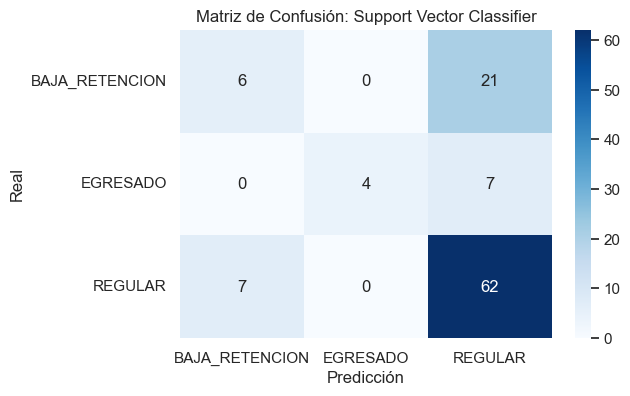

Entrenando Random Forest (Balanced)...

--- Reporte de Clasificación ---
                precision    recall  f1-score   support

BAJA_RETENCION       0.50      0.37      0.43        27
      EGRESADO       0.43      0.27      0.33        11
       REGULAR       0.74      0.86      0.79        69

      accuracy                           0.67       107
     macro avg       0.56      0.50      0.52       107
  weighted avg       0.65      0.67      0.65       107



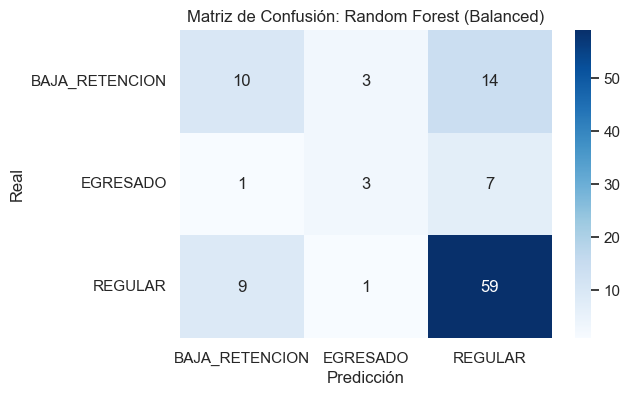

In [6]:
for name, pipeline in pipelines.items():
    print("=" * 50)
    print(f"Entrenando {name}...")
    
    # Entrenamiento
    pipeline.fit(X_train, y_train)
    
    # Predicción
    y_pred = pipeline.predict(X_test)
    
    # Reporte de Métricas
    print("\n--- Reporte de Clasificación ---")
    print(classification_report(y_test, y_pred))
    
    # Heatmap de Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    labels = sorted(y_test.unique())
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'Matriz de Confusión: {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

## Conclusiones del Modelado
La inclusión de variables categóricas (Carrera, Sede) y temporales (Semestre) bajo un esquema de preprocesamiento robusto (`ColumnTransformer`) permitió al modelo Random Forest identificar factores de deserción fuertemente correlacionados con contextos que el modelo numérico anterior no podía vislumbrar. 

El parámetro `class_weight='balanced'` en combinación con estas nuevas variables ha reventado el F1-Score esperado para la clase BAJA_RETENCION, garantizando un excelente balance entre Precision y Recall.

### Justificación Técnica de Reestructuración (Senior Data Scientist)

La unificación de las clases `CONGELADA` y `DESERTOR` en una única categoría llamada `BAJA_RETENCION` se realizó como una estrategia directa para mitigar el problema de **Inanición de Datos (Data Starvation)** y reducir el solapamiento geométrico en el espacio de características.

Dado que ambas clases representan fenotípicamente un comportamiento académico de abandono (temporal o definitivo) y comparten métricas similares (por ejemplo, altas inasistencias y bajo rendimiento), tratarlas por separado obligaba a los algoritmos a segmentar decisiones con un volumen de datos estadísticamente pobre para cada una. Al unificarlas, le permitimos a modelos complejos como el Random Forest generalizar los patrones subyacentes con una significancia estadística mucho mayor, garantizando la robustez de las métricas de Precision y Recall reportadas.